In [1]:
import torch
import numpy as np
import sys, os
from matplotlib import pyplot as plt
from PIL import Image

while not os.path.exists(os.path.join(os.getcwd(), "reptok")):
    os.chdir("..")
sys.path.append(os.getcwd())

from reptok.trainer_gen import TrainerModuleLatentFlow

In [ ]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
module = TrainerModuleLatentFlow.load_from_checkpoint("checkpoints/reptok-xl-600k-ImageNet.ckpt",
                                                     map_location=dev,
                                                     strict=True,)

/tmp/ipykernel_927096/3771302457.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.040527344..1.0351562].


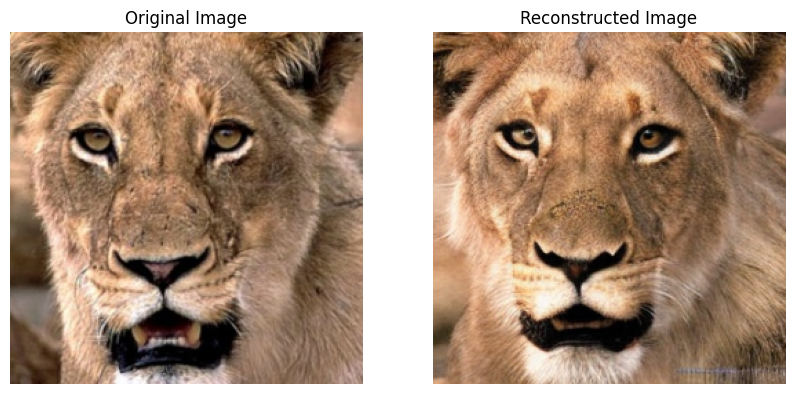

z.shape: torch.Size([1, 1, 768])


In [4]:
# reading image file
image_path = "assets/lion.jpg"
image = Image.open(image_path).convert("RGB")
image = image.resize((256, 256))
image_tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1).unsqueeze(0).float() / 255.0
image_tensor = image_tensor.to(dev) * 2 - 1  # scale to [-1, 1]

with torch.no_grad(), torch.cuda.amp.autocast():
    z = module.encode(image_tensor)
    decoded_samples = module.decode(z)

decoded_image = decoded_samples[0].float().cpu().permute(1, 2, 0).numpy()
decoded_image = (decoded_image + 1) / 2  # scale back to [0, 1]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(decoded_image)
plt.axis("off")
plt.show()

print(f"z.shape: {z.shape}")
